# Setup

### Import standard libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Import common library functions for print style, data wrangling, data imputation
- force reload when this cell is executed, as the lib functions change frequently and
we don't want to use the cached versions

In [2]:
# imports needed for reloading
import importlib
import sys
import os

# Add the 'assignments' folder to the system path so we can find the 'lib' module
# The 'lib' folder is 2 levels up from this notebook
sys.path.append(os.path.abspath('../../'))


# To avoid issues with cached python code that is often changing during development,
# we forcibly reload those modules
modules = ['lib.text_util', 'lib.wrangler', 'lib.imputer', 'lib.analyzer']

for module in modules:
    if module in sys.modules:
        importlib.reload(sys.modules[module])

# text helpers used to make text output more readable
import lib.text_util as tu

# data wrangling helpers
import lib.wrangler as wr

# data imputation helpers
import lib.imputer as im

# data analysis helpers
import lib.analyzer as da

# utility functions
import lib.utility as utl


# to test text_util, uncomment the following line
# tu.demo_text_print()

### Global configuration

In [3]:
# show dataframe values with commas and 2 decimal places
pd.options.display.float_format = '{:,.2f}'.format

### Read sales data, and show the dataframe

In [4]:
orig_sales = pd.read_csv('AusApparalSales4thQrt2020.csv')
orig_sales

,Date,Time,State,Group,Unit,Sales
0,1-Oct-2020,Morning,WA,Kids,8,20000
1,1-Oct-2020,Morning,WA,Men,8,20000
2,1-Oct-2020,Morning,WA,Women,4,10000
3,1-Oct-2020,Morning,WA,Seniors,15,37500
4,1-Oct-2020,Afternoon,WA,Kids,3,7500
...,...,...,...,...,...,...
7555,30-Dec-2020,Afternoon,TAS,Seniors,14,35000
7556,30-Dec-2020,Evening,TAS,Kids,15,37500
7557,30-Dec-2020,Evening,TAS,Men,15,37500
7558,30-Dec-2020,Evening,TAS,Women,11,27500


# 1. Data Wrangling


### clean the data

In [5]:
sales = wr.clean_object_columns_advanced(orig_sales, columns_case_styles={'State':'original'})


### display information about the data columns, and a sample of each

In [6]:
wr.print_col_info(sales)

Columns: ['Date', 'Time', 'State', 'Group', 'Unit', 'Sales']
Shape: (7560, 6)

Dtypes:
Date     object
Time     object
State    object
Group    object
Unit      int64
Sales     int64
dtype: object

Sample values for object columns:
Date: ['1-Oct-2020', '1-Oct-2020', '1-Oct-2020']
Time: ['Morning', 'Morning', 'Morning']
State: ['WA', 'WA', 'WA']
Group: ['Kids', 'Men', 'Women']


In [7]:
# we assign the returned dictionary to a dummy variable so that jupyter won't print the result
_ = wr.show_unique_values_for_object_columns(sales, max_unique=10)


📊 Column: Date
   Total unique values: 90
   First 10 values: ['1-Oct-2020', '2-Oct-2020', '3-Oct-2020', '4-Oct-2020', '5-Oct-2020', '6-Oct-2020', '7-Oct-2020', '8-Oct-2020', '9-Oct-2020', '10-Oct-2020']
   ... and 80 more
   Most frequent: 1-Oct-2020 (84 times)

📊 Column: Time
   Total unique values: 3
   Values: ['Morning', 'Afternoon', 'Evening']
   Most frequent: Morning (2520 times)

📊 Column: State
   Total unique values: 7
   Values: ['WA', 'NT', 'SA', 'VIC', 'QLD', 'NSW', 'TAS']
   Most frequent: WA (1080 times)

📊 Column: Group
   Total unique values: 4
   Values: ['Kids', 'Men', 'Women', 'Seniors']
   Most frequent: Kids (1890 times)


### show missing values

In [8]:
wr.print_missing_values_counts(sales)

Date     0
Time     0
State    0
Group    0
Unit     0
Sales    0
dtype: int64


Date     0
Time     0
State    0
Group    0
dtype: int64


### show dataframe info

In [9]:
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7560 entries, 0 to 7559
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Date    7560 non-null   object
 1   Time    7560 non-null   object
 2   State   7560 non-null   object
 3   Group   7560 non-null   object
 4   Unit    7560 non-null   int64 
 5   Sales   7560 non-null   int64 
dtypes: int64(2), object(4)
memory usage: 354.5+ KB


### show basic data statistics

In [10]:
sales.describe()

,Unit,Sales
count,"7,560.00","7,560.00"
mean,18.01,"45,013.56"
std,12.90,"32,253.51"
min,2.00,"5,000.00"
25%,8.00,"20,000.00"
50%,14.00,"35,000.00"
75%,26.00,"65,000.00"
max,65.00,"162,500.00"


## New Column Additions

### Convert DD-MMM-YYYY date strings into an actual date

In [11]:

# Convert Date column from string to datetime
# The format '%d-%b-%Y' matches DD-MMM-YYYY (e.g., "1-Oct-2020")
sales['Date'] = pd.to_datetime(sales['Date'], format='%d-%b-%Y')

# Verify the conversion
tu.print_heading("Date Column Conversion")
print(tu.bold_text("Date column info after conversion:"))
print(f"Data type: {sales['Date'].dtype}")
print(f"Sample values: {sales['Date'].head().tolist()}")

# Show the first few rows to confirm
print("\nFirst few rows with converted dates:")
print(sales[['Date', 'Time', 'State', 'Sales']].head())

Date column info after conversion:
Data type: datetime64[ns]
Sample values: [Timestamp('2020-10-01 00:00:00'), Timestamp('2020-10-01 00:00:00'), Timestamp('2020-10-01 00:00:00'), Timestamp('2020-10-01 00:00:00'), Timestamp('2020-10-01 00:00:00')]

First few rows with converted dates:
        Date       Time State  Sales
0 2020-10-01    Morning    WA  20000
1 2020-10-01    Morning    WA  20000
2 2020-10-01    Morning    WA  10000
3 2020-10-01    Morning    WA  37500
4 2020-10-01  Afternoon    WA   7500


### Add other date columns, week, month, quarter

In [12]:
sales['Week'] = sales['Date'].dt.isocalendar().week
sales['Month'] = sales['Date'].dt.month
sales['Quarter'] = sales['Date'].dt.quarter

# Missing values and new columns discussion

- We cleaned the data by trimming whitespace converting any missing values to np.nan.

- Triming whitespace cleaned up leading spaces from the object columns.

- No missing values were found. There were no column values found matching
  > DEFAULT_MISSING_VALUES = ("", "NA", "N/A", "-", "null", "None", "?")

- We converted the Date column into an actual date and added columns for week, month and quarter

- We found the following unique values for columns:
   - Time, 3 unique: ['Morning', 'Afternoon', 'Evening'], Most frequent: Morning (2520 times)
   - State, 7 uniques: ['WA', 'NT', 'SA', 'VIC', 'QLD', 'NSW', 'TAS'], Most frequent: WA (1080 times)
   - Group, 4 unique: ['Kids', 'Men', 'Women', 'Seniors'], Most frequent: Women (1040 times)

## Data Normalization

### Normalizing Unit and Sales data

In [13]:
# Data Normalization - as recommended in the requirements
from sklearn.preprocessing import MinMaxScaler

# Create a copy of the dataframe for normalization
sales_normalized = sales.copy()

# Apply normalization to numerical columns (Unit and Sales)
scaler = MinMaxScaler()
sales_normalized[['Unit_normalized', 'Sales_normalized']] = scaler.fit_transform(sales[['Unit', 'Sales']])

tu.print_heading("Original vs Normalized Samples")
tu.print_sub_heading("Original Data Sample:")
print(sales[['Unit', 'Sales', 'State', 'Group']].head())
tu.print_sub_heading("Normalized Data Sample:")
print(sales_normalized[['Unit_normalized', 'Sales_normalized', 'State', 'Group']].head())

   Unit  Sales State    Group
0     8  20000    WA     Kids
1     8  20000    WA      Men
2     4  10000    WA    Women
3    15  37500    WA  Seniors
4     3   7500    WA     Kids


   Unit_normalized  Sales_normalized State    Group
0             0.10              0.10    WA     Kids
1             0.10              0.10    WA      Men
2             0.03              0.03    WA    Women
3             0.21              0.21    WA  Seniors
4             0.02              0.02    WA     Kids


### NOTE: Normalization chosen instead of standardization.
We want all the features to contribute equally (bounded between 0-1)

## What normalized data reveals?
- We see that Sales and Unit columns normalize to the same value.
- This implies that all units are the same price.
- Sales and Unit columns convey the same information as to sales magnitude.

# 2. Data Analysis

### Group By Analysis

In [14]:
# GroupBy Analysis - as requested in requirements
tu.print_heading("GroupBy Analysis")

# Show sales and units by state
wr.show_group_by_analysis_multi(sales, 'State',
    { 'Sales': ['sum', 'mean', 'count'], 'Unit': ['sum', 'mean'] },
    "State-wise Sales Analysis", ['Sales','sum'])

# Show sales and units by demographic groups
wr.show_group_by_analysis_multi(sales, 'Group',
    {'Sales': ['sum', 'mean', 'count'],'Unit': ['sum', 'mean'] },
    "Demographic Group-wise Sales Analysis", ['Sales','sum'])

# Show sales and units by time of day
wr.show_group_by_analysis_multi(sales, 'Time',
    {'Sales': ['sum', 'mean', 'count'], 'Unit': ['sum', 'mean']},
    "Time-wise Sales Analysis", ['Sales','sum'])


None
                Sales                              Unit        
                  sum        mean     count         sum    mean
State                                                          
VIC    105,565,000.00   97,745.37  1,080.00   42,226.00   39.10
NSW     74,970,000.00   69,416.67  1,080.00   29,988.00   27.77
SA      58,857,500.00   54,497.69  1,080.00   23,543.00   21.80
QLD     33,417,500.00   30,942.13  1,080.00   13,367.00   12.38
TAS     22,760,000.00   21,074.07  1,080.00    9,104.00    8.43
NT      22,580,000.00   20,907.41  1,080.00    9,032.00    8.36
WA      22,152,500.00   20,511.57  1,080.00    8,861.00    8.20
Total  340,302,500.00  315,094.91  7,560.00  136,121.00  126.04



None
                  Sales                              Unit       
                    sum        mean     count         sum   mean
Group                                                           
Men       85,750,000.00   45,370.37  1,890.00   34,300.00  18.15
Women     85,442,500.00   45,207.67  1,890.00   34,177.00  18.08
Kids      85,072,500.00   45,011.90  1,890.00   34,029.00  18.00
Seniors   84,037,500.00   44,464.29  1,890.00   33,615.00  17.79
Total    340,302,500.00  180,054.23  7,560.00  136,121.00  72.02



None
                    Sales                              Unit       
                      sum        mean     count         sum   mean
Time                                                              
Morning    114,207,500.00   45,320.44  2,520.00   45,683.00  18.13
Afternoon  114,007,500.00   45,241.07  2,520.00   45,603.00  18.10
Evening    112,087,500.00   44,479.17  2,520.00   44,835.00  17.79
Total      340,302,500.00  135,040.68  7,560.00  136,121.00  54.02


### Group by analysis on normalized data

In [15]:
# GroupBy Analysis - as requested in requirements
tu.print_heading("GroupBy Analysis")

# Show sales and units by state
wr.show_group_by_analysis_multi(sales_normalized, 'State',
    { 'Sales_normalized': ['sum', 'mean', 'count'], 'Unit_normalized': ['sum', 'mean'] },
    "Normalized State-wise Sales Analysis", ['Sales_normalized','sum'])

# Show sales and units by demographic groups
wr.show_group_by_analysis_multi(sales_normalized, 'Group',
    {'Sales_normalized': ['sum', 'mean', 'count'],'Unit_normalized': ['sum', 'mean'] },
    "Normalized Demographic Group-wise Sales Analysis", ['Sales_normalized','sum'])

# Show sales and units by time of day
wr.show_group_by_analysis_multi(sales_normalized, 'Time',
    {'Sales_normalized': ['sum', 'mean', 'count'], 'Unit_normalized': ['sum', 'mean']},
    "Normalized Time-wise Sales Analysis", ['Sales_normalized','sum'])


None
      Sales_normalized                 Unit_normalized      
                   sum  mean     count             sum  mean
State                                                       
VIC             635.97  0.59  1,080.00          635.97  0.59
NSW             441.71  0.41  1,080.00          441.71  0.41
SA              339.41  0.31  1,080.00          339.41  0.31
QLD             177.89  0.16  1,080.00          177.89  0.16
TAS             110.22  0.10  1,080.00          110.22  0.10
NT              109.08  0.10  1,080.00          109.08  0.10
WA              106.37  0.10  1,080.00          106.37  0.10
Total         1,920.65  1.77  7,560.00        1,920.65  1.77



None
        Sales_normalized                 Unit_normalized      
                     sum  mean     count             sum  mean
Group                                                         
Men               484.44  0.26  1,890.00          484.44  0.26
Women             482.49  0.26  1,890.00          482.49  0.26
Kids              480.14  0.25  1,890.00          480.14  0.25
Seniors           473.57  0.25  1,890.00          473.57  0.25
Total           1,920.64  1.02  7,560.00        1,920.64  1.02



None
          Sales_normalized                 Unit_normalized      
                       sum  mean     count             sum  mean
Time                                                            
Morning             645.13  0.26  2,520.00          645.13  0.26
Afternoon           643.86  0.26  2,520.00          643.86  0.26
Evening             631.67  0.25  2,520.00          631.67  0.25
Total             1,920.66  0.77  7,560.00        1,920.66  0.77


### perform variance analysis for Sales grouped by state

       count        sum      mean       std            var    min     max  \
State                                                                       
NSW     1080   74970000 69,416.67 20,626.65 425,458,758.11  30000  112500   
NT      1080   22580000 20,907.41  8,961.91  80,315,793.09   5000   37500   
QLD     1080   33417500 30,942.13 13,344.64 178,079,363.39   7500   62500   
SA      1080   58857500 54,497.69 17,460.97 304,885,305.11  25000   87500   
TAS     1080   22760000 21,074.07  9,024.68  81,444,925.00   5000   37500   
VIC     1080  105565000 97,745.37 26,621.60 708,709,431.74  50000  162500   
WA      1080   22152500 20,511.57  9,231.91  85,228,086.49   5000   37500   

         median  
State            
NSW   70,000.00  
NT    20,000.00  
QLD   30,000.00  
SA    52,500.00  
TAS   20,000.00  
VIC   95,000.00  
WA    20,000.00  


     NSW:  29.71% (std: $20,626.65)
      NT:  42.86% (std: $8,961.91)
     QLD:  43.13% (std: $13,344.64)
      SA:  32.04% (std: $17,460.97)
     TAS:  42.82% (std: $9,024.68)
     VIC:  27.24% (std: $26,621.60)
      WA:  45.01% (std: $9,231.91)
F-statistic: 3662.5905
P-value: 0.000000
✅ Significant difference exists between groups (p < 0.05)


     NSW: Range = $82,500.00 ($30,000.00 to $112,500.00)
      NT: Range = $32,500.00 ($5,000.00 to $37,500.00)
     QLD: Range = $55,000.00 ($7,500.00 to $62,500.00)
      SA: Range = $62,500.00 ($25,000.00 to $87,500.00)
     TAS: Range = $32,500.00 ($5,000.00 to $37,500.00)
     VIC: Range = $112,500.00 ($50,000.00 to $162,500.00)
      WA: Range = $32,500.00 ($5,000.00 to $37,500.00)


NSW Group:
  25th percentile: $52,500.00
  50th percentile: $70,000.00
  75th percentile: $85,000.00
  90th percentile: $97,500.00
  95th percentile: $102,500.00

NT Group:
  25th percentile: $15,000.00
  50th percentile: $20,000.00
  75th percentile: $27,500.00
  90th percentile: $35,000.00
  95th percentile: $35,000.00

QLD Group:
  25th percentile: $20,000.00
  50th percentile: $30,000.00
  75th percentile: $40,000.00
  90th percentile: $50,000.00
  95th percentile: $55,000.00

SA Group:
  25th percentile: $40,000.00
  50th percentile: $52,500.00
  75th percentile: $67,500.00
  90th percentile: $80,000.00
  95th percentile: $85,000.00

TAS Group:
  25th percentile: $15,000.00
  50th percentile: $20,000.00
  75th percentile: $27,500.00
  90th percentile: $35,000.00
  95th percentile: $37,500.00

VIC Group:
  25th percentile: $77,500.00
  50th percentile: $95,000.00
  75th percentile: $112,500.00
  90th percentile: $137,500.00
  95th percentile: $152,500.00

WA Group:
  25th percentil

group_std: State
NSW   20,626.65
NT     8,961.91
QLD   13,344.64
SA    17,460.97
TAS    9,024.68
VIC   26,621.60
WA     9,231.91
Name: Sales, dtype: float64


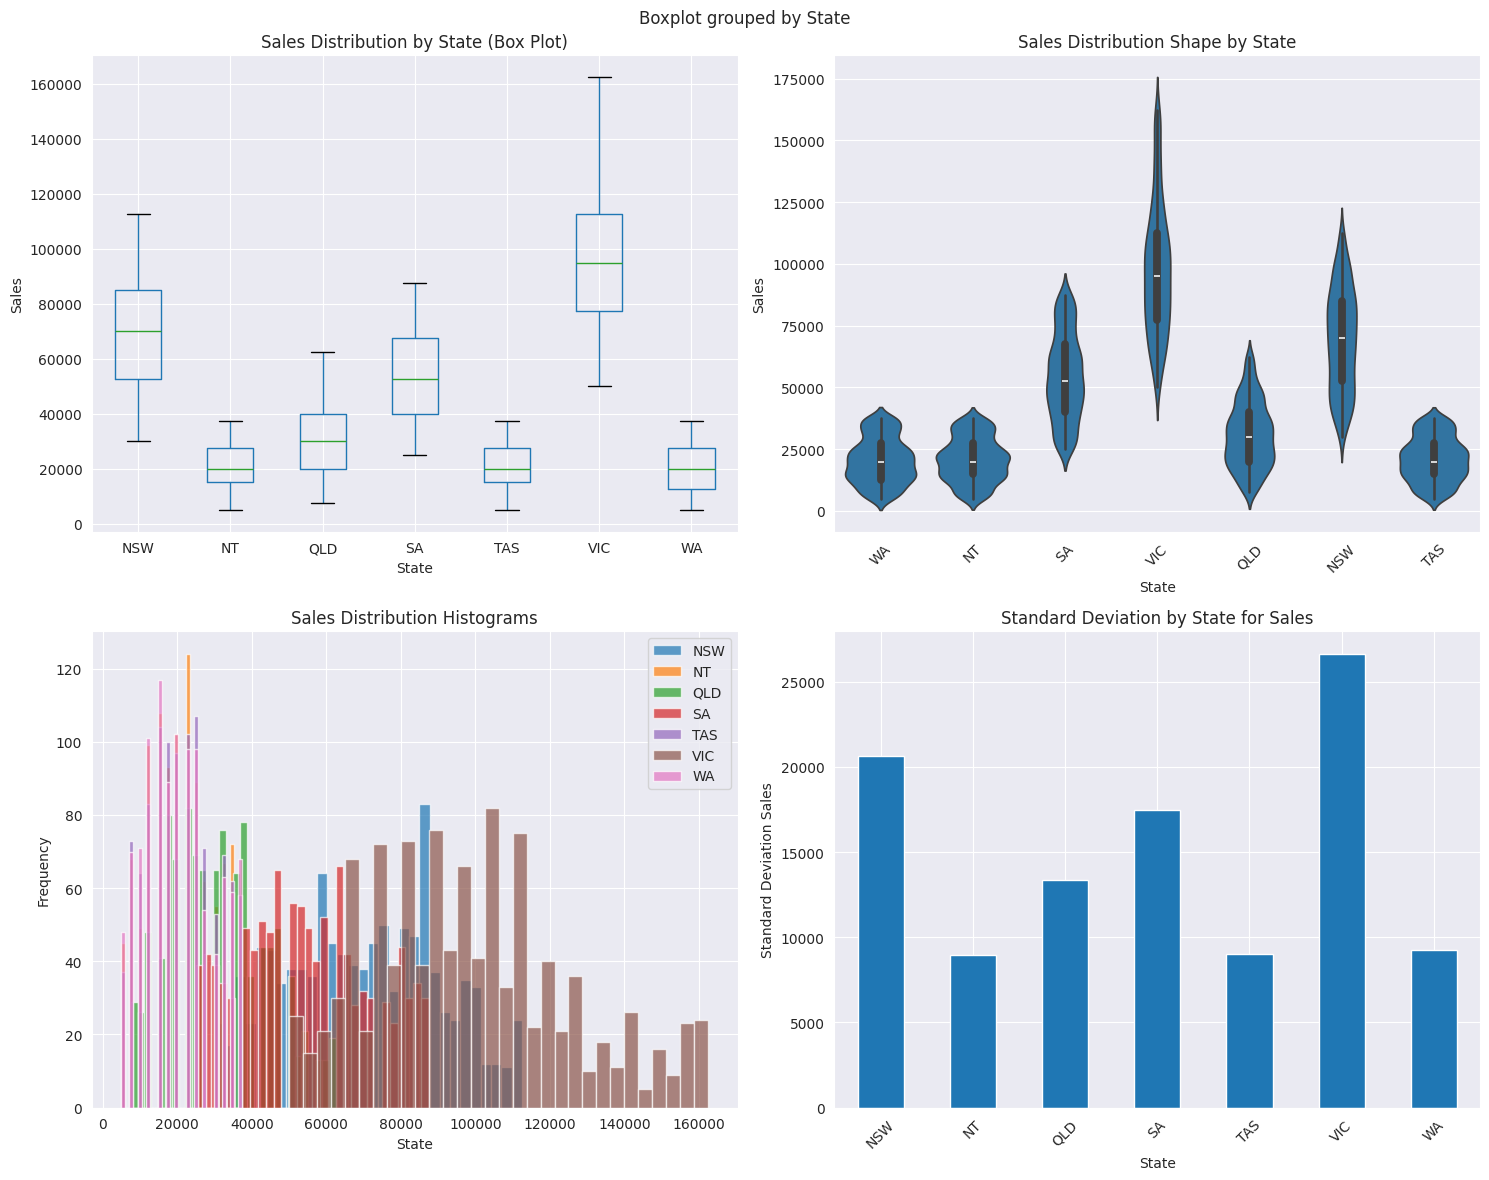

     NSW variance: $425,458,758.11
      NT variance: $80,315,793.09
     QLD variance: $178,079,363.39
      SA variance: $304,885,305.11
     TAS variance: $81,444,925.00
     VIC variance: $708,709,431.74
      WA variance: $85,228,086.49

Total variance: $1,040,288,710.18
Within-group variance: $266,162,137.66
Between-group variance: $774,126,572.52
Variance ratio (between/within): 2.9085


In [16]:
da.anova_for_column(sales, 'State', 'Sales')

### perform variance analysis for Sales grouped by 'Group'

         count       sum      mean       std              var   min     max  \
Group                                                                         
Kids      1890  85072500 45,011.90 31,871.49 1,015,791,943.96  5000  162500   
Men       1890  85750000 45,370.37 32,177.18 1,035,370,958.57  5000  160000   
Seniors   1890  84037500 44,464.29 32,195.36 1,036,541,206.61  5000  162500   
Women     1890  85442500 45,207.67 32,781.64 1,074,635,912.52  5000  162500   

           median  
Group              
Kids    35,000.00  
Men     35,000.00  
Seniors 35,000.00  
Women   35,000.00  


    Kids:  70.81% (std: $31,871.49)
     Men:  70.92% (std: $32,177.18)
 Seniors:  72.41% (std: $32,195.36)
   Women:  72.51% (std: $32,781.64)
F-statistic: 0.2826
P-value: 0.838035
❌ No significant difference between groups (p >= 0.05)


    Kids: Range = $157,500.00 ($5,000.00 to $162,500.00)
     Men: Range = $155,000.00 ($5,000.00 to $160,000.00)
 Seniors: Range = $157,500.00 ($5,000.00 to $162,500.00)
   Women: Range = $157,500.00 ($5,000.00 to $162,500.00)


Kids Group:
  25th percentile: $20,000.00
  50th percentile: $35,000.00
  75th percentile: $65,000.00
  90th percentile: $92,500.00
  95th percentile: $107,500.00

Men Group:
  25th percentile: $20,000.00
  50th percentile: $35,000.00
  75th percentile: $65,000.00
  90th percentile: $92,500.00
  95th percentile: $107,500.00

Seniors Group:
  25th percentile: $20,000.00
  50th percentile: $35,000.00
  75th percentile: $62,500.00
  90th percentile: $90,000.00
  95th percentile: $107,500.00

Women Group:
  25th percentile: $20,000.00
  50th percentile: $35,000.00
  75th percentile: $67,500.00
  90th percentile: $92,500.00
  95th percentile: $107,500.00



group_std: Group
Kids      31,871.49
Men       32,177.18
Seniors   32,195.36
Women     32,781.64
Name: Sales, dtype: float64


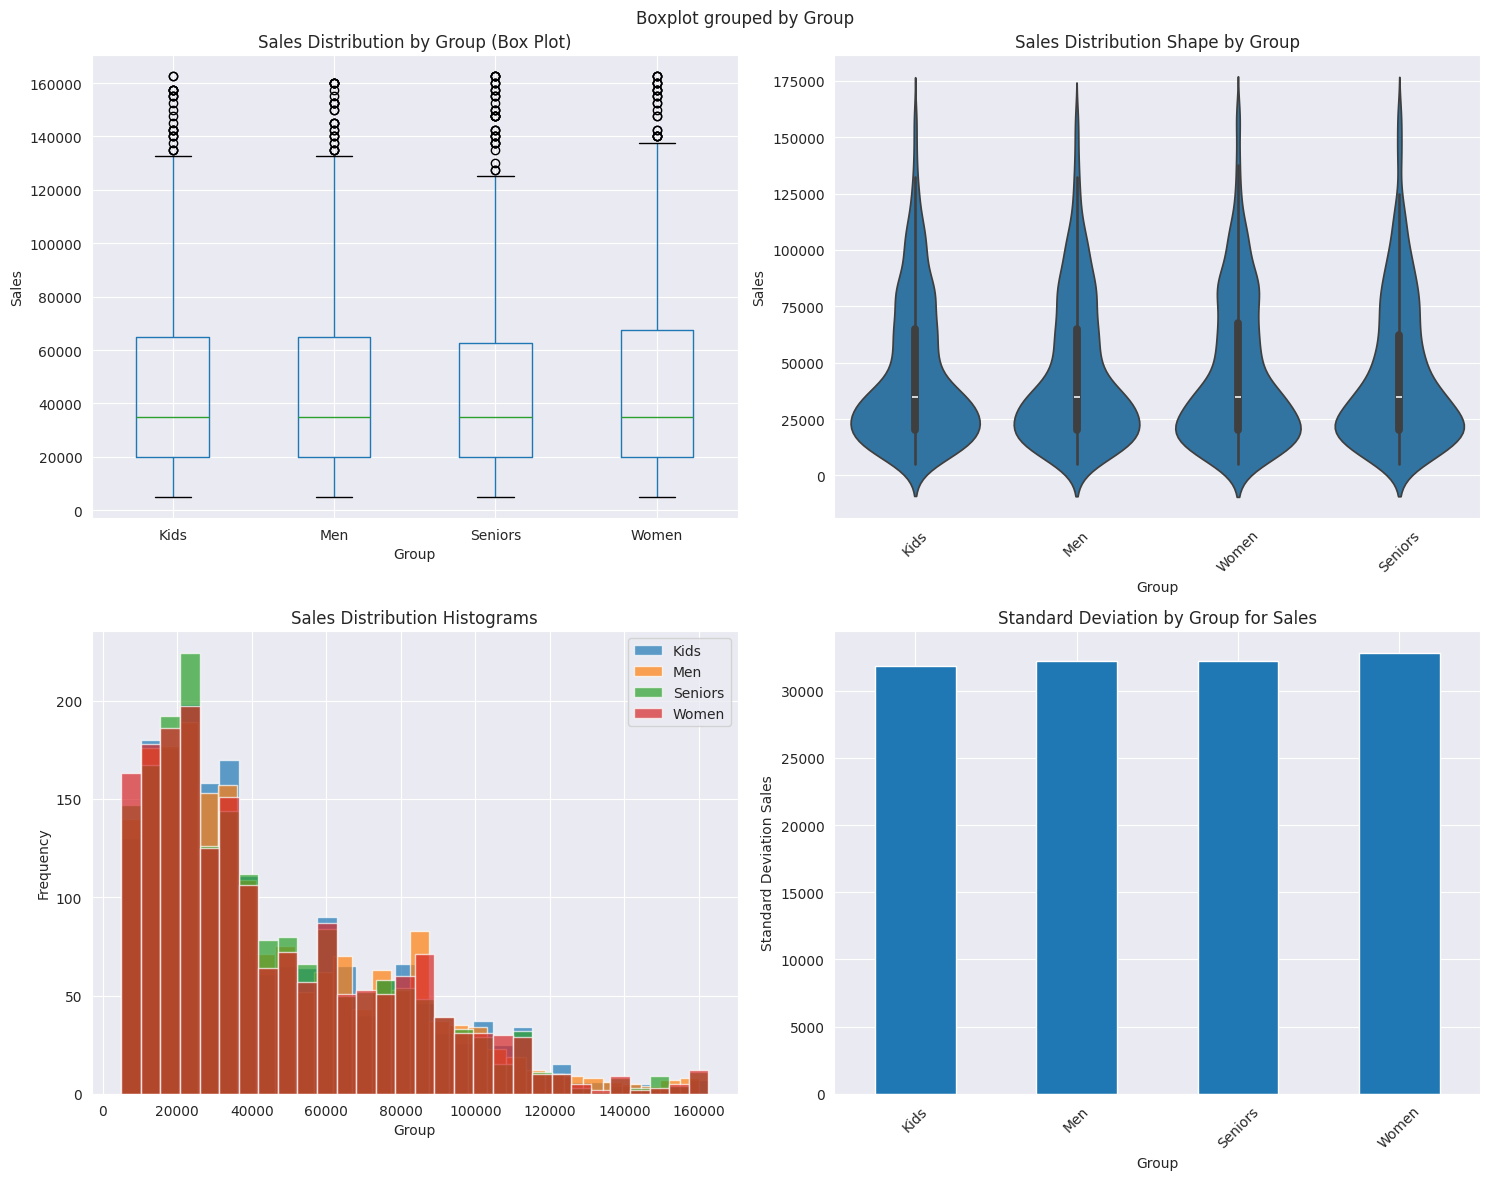

    Kids variance: $1,015,791,943.96
     Men variance: $1,035,370,958.57
 Seniors variance: $1,036,541,206.61
   Women variance: $1,074,635,912.52

Total variance: $1,040,288,710.18
Within-group variance: $1,040,447,307.25
Between-group variance: $-158,597.07
Variance ratio (between/within): -0.0002


In [17]:
da.anova_for_column(sales, 'Group', 'Sales')

In [18]:

# Descriptive Statistical Analysis
tu.print_heading("Descriptive Statistical Analysis")

print("Sales Column Statistics:")
print(f"Mean: {sales['Sales'].mean():.2f}")
print(f"Median: {sales['Sales'].median():.2f}")
print(f"Mode: {sales['Sales'].mode().iloc[0]:.2f}")
print(f"Standard Deviation: {sales['Sales'].std():.2f}")

print("\nUnit Column Statistics:")
print(f"Mean: {sales['Unit'].mean():.2f}")
print(f"Median: {sales['Unit'].median():.2f}")
print(f"Mode: {sales['Unit'].mode().iloc[0]:.2f}")
print(f"Standard Deviation: {sales['Unit'].std():.2f}")

# Identify highest and lowest performing groups
tu.print_heading("Group Performance Analysis")

# Highest and lowest sales by group
group_sales = sales.groupby('Group')['Sales'].sum().sort_values(ascending=False)
print("Sales by Group (Total):")
print(group_sales)

print(f"\nHighest performing group: {group_sales.index[0]} with ${group_sales.iloc[0]:,.2f}")
print(f"Lowest performing group: {group_sales.index[-1]} with ${group_sales.iloc[-1]:,.2f}")

# Highest and lowest sales by state
state_sales = sales.groupby('State')['Sales'].sum().sort_values(ascending=False)
print("\nSales by State (Total):")
print(state_sales)

print(f"\nHighest performing state: {state_sales.index[0]} with ${state_sales.iloc[0]:,.2f}")
print(f"Lowest performing state: {state_sales.index[-1]} with ${state_sales.iloc[-1]:,.2f}")

Sales Column Statistics:
Mean: 45013.56
Median: 35000.00
Mode: 22500.00
Standard Deviation: 32253.51

Unit Column Statistics:
Mean: 18.01
Median: 14.00
Mode: 9.00
Standard Deviation: 12.90


Sales by Group (Total):
Group
Men        85750000
Women      85442500
Kids       85072500
Seniors    84037500
Name: Sales, dtype: int64

Highest performing group: Men with $85,750,000.00
Lowest performing group: Seniors with $84,037,500.00

Sales by State (Total):
State
VIC    105565000
NSW     74970000
SA      58857500
QLD     33417500
TAS     22760000
NT      22580000
WA      22152500
Name: Sales, dtype: int64

Highest performing state: VIC with $105,565,000.00
Lowest performing state: WA with $22,152,500.00


### Time based analysis

In [19]:
# Weekly Reports
tu.print_heading("Weekly Sales Report")
weekly_sales = sales.groupby(['Week', 'State'])['Sales'].sum().unstack(fill_value=0)
print(wr.add_commas(weekly_sales.head(10)))

# Monthly Reports
tu.print_heading("Monthly Sales Report")
monthly_sales = sales.groupby(['Month', 'State'])['Sales'].sum().unstack(fill_value=0)
print(wr.add_commas(monthly_sales))

# Quarterly Reports
tu.print_heading("Quarterly Sales Report")
quarterly_sales = sales.groupby(['Quarter', 'State'])['Sales'].sum().unstack(fill_value=0)
print(wr.add_commas(quarterly_sales))


State           NSW            NT           QLD            SA           TAS  \
Week                                                                          
40     3,382,500.00  1,052,500.00  1,627,500.00  2,542,500.00  1,052,500.00   
41     5,892,500.00  1,937,500.00  2,545,000.00  4,942,500.00  1,947,500.00   
42     5,717,500.00  1,935,000.00  2,637,500.00  4,822,500.00  1,845,000.00   
43     5,922,500.00  1,907,500.00  2,592,500.00  4,832,500.00  1,907,500.00   
44     4,822,500.00  1,520,000.00  1,997,500.00  3,987,500.00  1,477,500.00   
45     4,915,000.00  1,150,000.00  1,825,000.00  3,772,500.00  1,312,500.00   
46     4,957,500.00  1,247,500.00  1,905,000.00  3,650,000.00  1,287,500.00   
47     4,987,500.00  1,282,500.00  1,875,000.00  3,572,500.00  1,227,500.00   
48     5,147,500.00  1,267,500.00  1,957,500.00  3,555,000.00  1,300,000.00   
49     6,277,500.00  1,937,500.00  2,997,500.00  5,002,500.00  2,097,500.00   

State           VIC            WA  
Week           

State            NSW            NT            QLD             SA  \
Month                                                              
10     25,007,500.00  8,222,500.00  11,120,000.00  20,610,000.00   
11     21,490,000.00  5,257,500.00   8,110,000.00  15,532,500.00   
12     28,472,500.00  9,100,000.00  14,187,500.00  22,715,000.00   

State           TAS            VIC            WA  
Month                                             
10     8,015,000.00  33,442,500.00  7,872,500.00  
11     5,545,000.00  29,530,000.00  5,217,500.00  
12     9,200,000.00  42,592,500.00  9,062,500.00  


State              NSW             NT            QLD             SA  \
Quarter                                                               
4        74,970,000.00  22,580,000.00  33,417,500.00  58,857,500.00   

State              TAS             VIC             WA  
Quarter                                                
4        22,760,000.00  105,565,000.00  22,152,500.00  


# 3. Data Visualizations

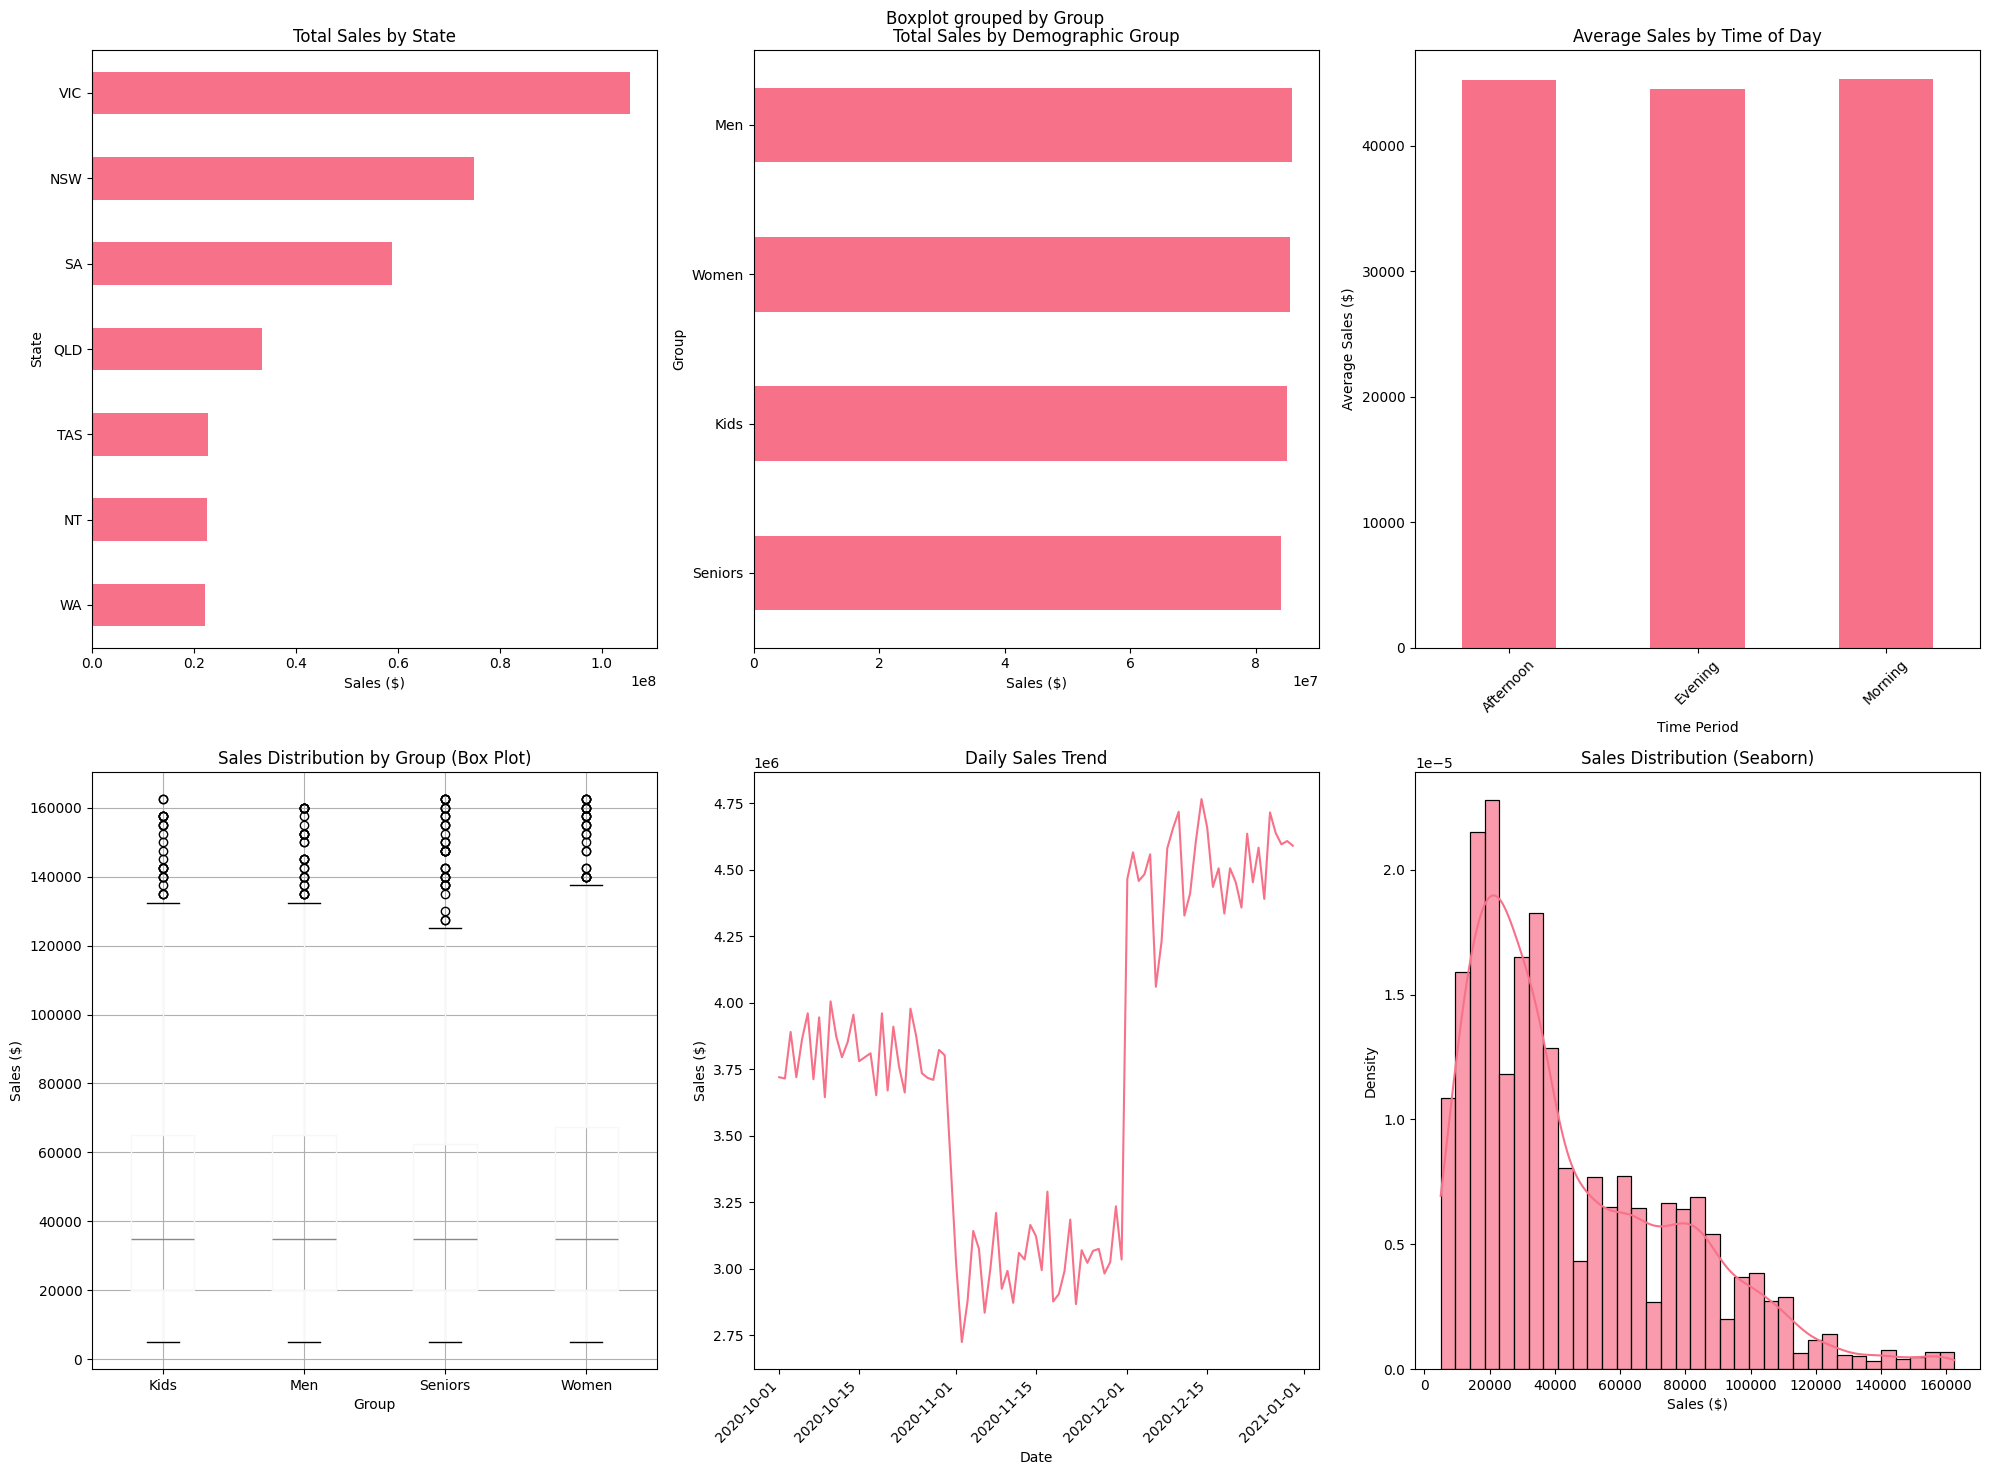

In [20]:
# Set up the plotting style
plt.style.use('default')
sns.set_palette("husl")

# Create figure with multiple subplots for dashboard
fig = plt.figure(figsize=(20, 15))

# 1. State-wise sales analysis
plt.subplot(2, 3, 1)
state_sales_viz = sales.groupby('State')['Sales'].sum().sort_values(ascending=True)
state_sales_viz.plot(kind='barh')
plt.title('Total Sales by State')
plt.xlabel('Sales ($)')

# 2. Group-wise sales analysis
plt.subplot(2, 3, 2)
group_sales_viz = sales.groupby('Group')['Sales'].sum().sort_values(ascending=True)
group_sales_viz.plot(kind='barh')
plt.title('Total Sales by Demographic Group')
plt.xlabel('Sales ($)')

# 3. Time of day analysis
plt.subplot(2, 3, 3)
time_sales = sales.groupby('Time')['Sales'].mean()
time_sales.plot(kind='bar')
plt.title('Average Sales by Time of Day')
plt.xlabel('Time Period')
plt.ylabel('Average Sales ($)')
plt.xticks(rotation=45)

# 4. Box plot for descriptive statistics (as required)
plt.subplot(2, 3, 4)
sales.boxplot(column='Sales', by='Group', ax=plt.gca())
plt.title('Sales Distribution by Group (Box Plot)')
plt.xlabel('Group')
plt.ylabel('Sales ($)')

# 5. Daily sales trend
plt.subplot(2, 3, 5)
daily_sales = sales.groupby('Date')['Sales'].sum()
daily_sales.plot()
plt.title('Daily Sales Trend')
plt.xlabel('Date')
plt.ylabel('Sales ($)')
plt.xticks(rotation=45)

# 6. Seaborn distribution plot (as required)
plt.subplot(2, 3, 6)
#sns.histplot(sales['Sales'], kde=True)
sns.histplot(data=sales, x='Sales', kde=True, stat='density', alpha=0.7)
plt.title('Sales Distribution (Seaborn)')
plt.xlabel('Sales ($)')


plt.tight_layout()
plt.show()

### Additional visualizations

<Figure size 1500x1000 with 0 Axes>

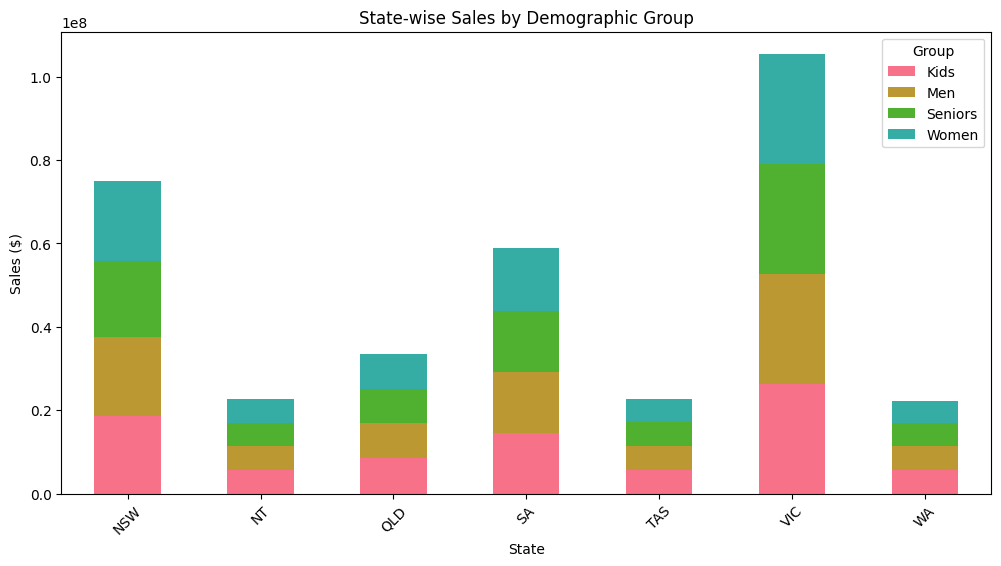

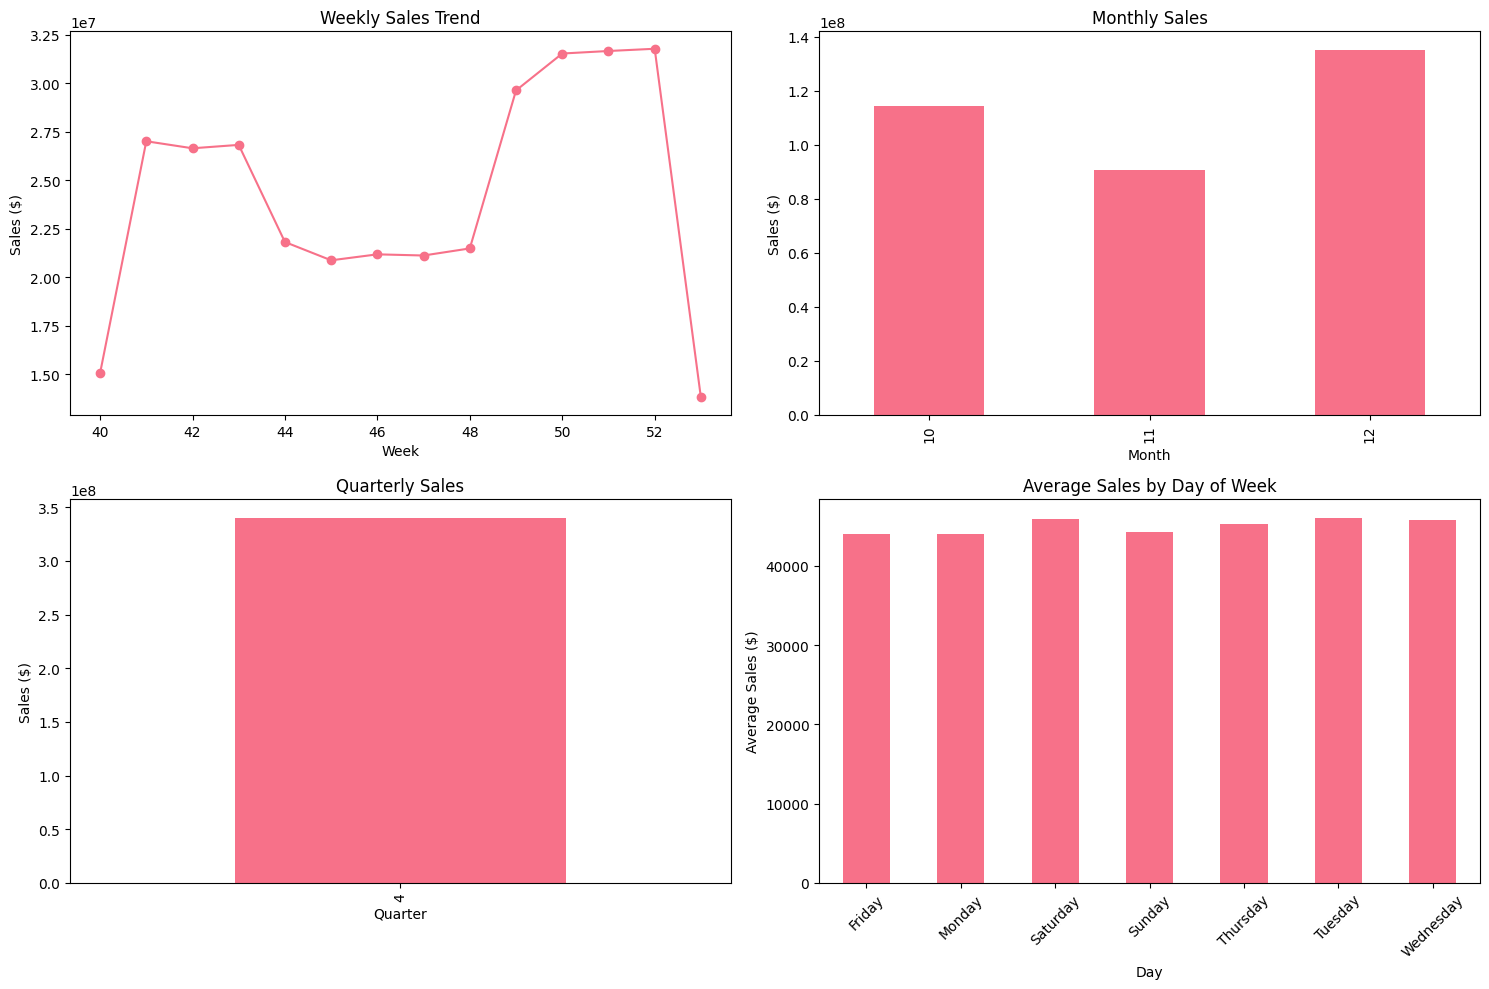

In [21]:
# Detailed State-wise and Group-wise Analysis
tu.print_heading("Detailed Visualization Analysis")

# State-wise sales by demographic group
plt.figure(figsize=(15, 10))
pivot_state_group = sales.groupby(['State', 'Group'])['Sales'].sum().unstack()
pivot_state_group.plot(kind='bar', stacked=True, figsize=(12, 6))
plt.title('State-wise Sales by Demographic Group')
plt.xlabel('State')
plt.ylabel('Sales ($)')
plt.legend(title='Group')
plt.xticks(rotation=45)
plt.show()

# Time-based analysis charts
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Weekly chart
weekly_total = sales.groupby('Week')['Sales'].sum()
weekly_total.plot(ax=axes[0,0], kind='line', marker='o')
axes[0,0].set_title('Weekly Sales Trend')
axes[0,0].set_xlabel('Week')
axes[0,0].set_ylabel('Sales ($)')

# Monthly chart
monthly_total = sales.groupby('Month')['Sales'].sum()
monthly_total.plot(ax=axes[0,1], kind='bar')
axes[0,1].set_title('Monthly Sales')
axes[0,1].set_xlabel('Month')
axes[0,1].set_ylabel('Sales ($)')

# Quarterly chart
quarterly_total = sales.groupby('Quarter')['Sales'].sum()
quarterly_total.plot(ax=axes[1,0], kind='bar')
axes[1,0].set_title('Quarterly Sales')
axes[1,0].set_xlabel('Quarter')
axes[1,0].set_ylabel('Sales ($)')

# Daily average by day of week
sales['DayOfWeek'] = sales['Date'].dt.day_name()
daily_avg = sales.groupby('DayOfWeek')['Sales'].mean()
daily_avg.plot(ax=axes[1,1], kind='bar')
axes[1,1].set_title('Average Sales by Day of Week')
axes[1,1].set_xlabel('Day')
axes[1,1].set_ylabel('Average Sales ($)')
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# 4. Report Findings

In [22]:
tu.print_heading("Key Findings and Recommendations")

# Calculate key metrics for recommendations
highest_state = sales.groupby('State')['Sales'].sum().idxmax()
lowest_state = sales.groupby('State')['Sales'].sum().idxmin()
best_time = sales.groupby('Time')['Sales'].mean().idxmax()
best_group = sales.groupby('Group')['Sales'].sum().idxmax()

tu.print_sub_heading("📊 KEY FINDINGS:")
print(f"• Highest Revenue State: {highest_state}")
print(f"• Lowest Revenue State: {lowest_state}")
print(f"• Best Performing Time: {best_time}")
print(f"• Best Performing Group: {best_group}")
print(f"• Total Q4 Revenue: ${sales['Sales'].sum():,.2f}")
print(f"• Average Daily Revenue: ${sales.groupby('Date')['Sales'].sum().mean():,.2f}")

tu.print_sub_heading("🎯 RECOMMENDATIONS:")
print(f"1. EXPAND IN HIGH-PERFORMING STATES:")
print(f"   - Focus expansion efforts in {highest_state} which shows highest revenue")
print(f"   - Replicate successful strategies from {highest_state} in other states")

print(f"\n2. DEVELOP PROGRAMS FOR LOWER-PERFORMING STATES:")
print(f"   - Create targeted marketing campaigns for {lowest_state}")
print(f"   - Investigate local preferences and adjust product mix")

print(f"\n3. OPTIMIZE TIME-BASED OPERATIONS:")
print(f"   - Peak sales period is {best_time} - ensure adequate staffing")
print(f"   - Consider promotional activities during off-peak hours")

print(f"\n4. DEMOGRAPHIC FOCUS:")
print(f"   - {best_group} segment generates highest revenue - maintain focus")
print(f"   - Develop targeted campaigns for underperforming segments")

tu.print_sub_heading("📈 VISUALIZATION PACKAGE RECOMMENDATION:")
print("SEABORN is recommended because:")
print("• Specifically designed for statistical data visualization")
print("• Excellent integration with pandas DataFrames")
print("• Beautiful default color palettes and themes")
print("• Built-in statistical plotting functions")
print("• Perfect for business intelligence dashboards")


• Highest Revenue State: VIC
• Lowest Revenue State: WA
• Best Performing Time: Morning
• Best Performing Group: Men
• Total Q4 Revenue: $340,302,500.00
• Average Daily Revenue: $3,781,138.89


1. EXPAND IN HIGH-PERFORMING STATES:
   - Focus expansion efforts in VIC which shows highest revenue
   - Replicate successful strategies from VIC in other states

2. DEVELOP PROGRAMS FOR LOWER-PERFORMING STATES:
   - Create targeted marketing campaigns for WA
   - Investigate local preferences and adjust product mix

3. OPTIMIZE TIME-BASED OPERATIONS:
   - Peak sales period is Morning - ensure adequate staffing
   - Consider promotional activities during off-peak hours

4. DEMOGRAPHIC FOCUS:
   - Men segment generates highest revenue - maintain focus
   - Develop targeted campaigns for underperforming segments


SEABORN is recommended because:
• Specifically designed for statistical data visualization
• Excellent integration with pandas DataFrames
• Beautiful default color palettes and themes
• Built-in statistical plotting functions
• Perfect for business intelligence dashboards



# Additional Observations
## Daily, Weekly and Monthly sales
- The highest sales at the start the last month of the 4th quarter
- Better sales at the beginning of the 4th quarter
- Recommendation, monitor these trends to determine the cause.
- Consider increased marketing during slower periods in the quarter to see how they affect outcomes
- Sales are fairly uniform throughout the week

## Average Sales by time of day
- Shows that sales volume isn't affected by time of day

## Total Sales by State
- There is statistically significant difference in sales between states
- We see the hightest sales in VIC and NSW
- Review the marketing strategies used for these higest performers and try applying them to low performing states to see if sales can be increased
- Looking at the transaction ranges for the various states, it would make sense to analyze data about population density and median incomes. Income and size differences may best explain the high sales in the best performing states.


## State-wise Sales by Demographic Group
- Within a given state there seems to be remarkable uniformity among the groups.


## Demographic group effect on Sales
- In total Men out perform other groups and Seniors come in last.
- Is there something in the marketing that appeals more to men or is the product just more suited for them?
- The diffences between groups is not huge.
- Variance analysis shows there is is not a significant difference in sales between groups:
  - F-statistic: 0.2826
  - P-value: 0.838035
  -  No significant difference between groups (p >= 0.05)

## Data normalization reveals
- Unit and Sales are capturing the same information, probably because they differ only by a constant factor, price.
- So it's sufficient to look at only one of these values to capture the correlation with other features.